# Clasificación de Palabras en LSM — ITESO-MX-100

Este notebook clasifica **palabras** (no letras) del Lenguaje de Señas Mexicano usando
**MediaPipe Holistic** para capturar ambas manos y el cuerpo, y modelos de ML para clasificación.

## Palabras a clasificar (primeras 10 del dataset)
`Abrir, Agua, Anaranjado, Apartar, Aprender, Aquí, Avión, Ayer, Ayudar, Azul`

## Diferencias clave vs. señas de letras
| Aspecto | Letras (MSL_Dynamic_Signs) | Palabras (este notebook) |
|---------|--------------------------|-------------------------|
| Detector | MediaPipe **Hands** (1 mano) | MediaPipe **Holistic** (2 manos + cuerpo) |
| Features/frame | 63 | 258 |
| Frames | 30 | 60 |
| Features totales | 378 | 1,548 |
| Train/test split | Pre-existente | **Generado en código (80/20 estratificado)** |

## Estrategia de dos fases
1. **Fase 1** — Mismo enfoque estadístico (mean, std, min, max, vel) con RF / SVM / GB
2. **Fase 2** — Modelo secuencial (MLP sobre la secuencia completa aplanada)

---
## PASO 1. Instalar e importar librerías

In [ ]:
!pip install mediapipe scikit-learn tqdm matplotlib seaborn -q

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.neural_network import MLPClassifier

print(f"MediaPipe v{mp.__version__}")
print("Librerias cargadas")

MediaPipe v0.10.9
Librerias cargadas


---
## PASO 2. Configuración

In [2]:
# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================

DATASET_BASE = "./datasets/ITESO-MX-100"

# Las primeras 10 palabras en orden alfabético del dataset
WORDS = [
    "Abrir", "Agua", "Anaranjado", "Apartar", "Aprender",
    "Aquí", "Avión", "Ayer", "Ayudar", "Azul"
]

# Más frames que letras: las palabras duran más
MAX_FRAMES   = 60

# Proporción del dataset para prueba
TEST_SIZE    = 0.20   # 80% train, 20% test
RANDOM_STATE = 42

# ── MediaPipe Holistic landmarks ────────────────────────────
# Mano izquierda : 21 lm × 3 coords = 63
# Mano derecha   : 21 lm × 3 coords = 63
# Pose (cuerpo)  : 33 lm × 4 coords = 132  (x, y, z, visibility)
# Total por frame: 258
N_FEATURES_PER_FRAME = 63 + 63 + 132  # 258

print(f"Dataset       : {DATASET_BASE}")
print(f"Palabras      : {WORDS}")
print(f"Max frames    : {MAX_FRAMES}")
print(f"Test size     : {TEST_SIZE:.0%}")
print(f"Features/frame: {N_FEATURES_PER_FRAME}")
print(f"Features total: {N_FEATURES_PER_FRAME * 6} (después de aggregation)")
print(f"Dataset existe : {os.path.exists(DATASET_BASE)}")

Dataset       : ./datasets/ITESO-MX-100
Palabras      : ['Abrir', 'Agua', 'Anaranjado', 'Apartar', 'Aprender', 'Aquí', 'Avión', 'Ayer', 'Ayudar', 'Azul']
Max frames    : 60
Test size     : 20%
Features/frame: 258
Features total: 1548 (después de aggregation)
Dataset existe : True


---
## PASO 3. Explorar el dataset y crear el split train/test

In [3]:
# ============================================================
# PASO 3. ESCANEAR DATASET Y CREAR SPLIT ESTRATIFICADO
# ============================================================

def scan_dataset(base_path, words):
    """
    Recorre cada carpeta de palabra y registra todos sus videos.
    Devuelve un DataFrame con columnas: [path, label]
    """
    records = []
    for word in words:
        folder = os.path.join(base_path, word)
        if not os.path.isdir(folder):
            print(f"  AVISO: Carpeta no encontrada: {folder}")
            continue
        videos = sorted(glob(os.path.join(folder, "*.mp4")))
        for v in videos:
            records.append({"path": v, "label": word})
        print(f"  {word:15s}: {len(videos)} videos")
    return pd.DataFrame(records)


print("Escaneando dataset...")
df_all = scan_dataset(DATASET_BASE, WORDS)

print(f"\nTotal de videos: {len(df_all)}")
print(df_all["label"].value_counts().sort_index())

Escaneando dataset...
  Abrir          : 49 videos
  Agua           : 54 videos
  Anaranjado     : 45 videos
  Apartar        : 49 videos
  Aprender       : 52 videos
  Aquí           : 53 videos
  Avión          : 52 videos
  Ayer           : 51 videos
  Ayudar         : 52 videos
  Azul           : 56 videos

Total de videos: 513
label
Abrir         49
Agua          54
Anaranjado    45
Apartar       49
Aprender      52
Aquí          53
Avión         52
Ayer          51
Ayudar        52
Azul          56
Name: count, dtype: int64


In [4]:
# ============================================================
# SPLIT ESTRATIFICADO 80/20
# train_test_split con stratify garantiza que cada clase
# tenga la misma proporción en train y test.
# ============================================================

df_train, df_test = train_test_split(
    df_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_all["label"]
)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train: {len(df_train)} videos")
print(f"Test : {len(df_test)} videos")
print("\nDistribución train:")
print(df_train["label"].value_counts().sort_index())
print("\nDistribución test:")
print(df_test["label"].value_counts().sort_index())

Train: 410 videos
Test : 103 videos

Distribución train:
label
Abrir         39
Agua          43
Anaranjado    36
Apartar       39
Aprender      42
Aquí          42
Avión         42
Ayer          41
Ayudar        41
Azul          45
Name: count, dtype: int64

Distribución test:
label
Abrir         10
Agua          11
Anaranjado     9
Apartar       10
Aprender      10
Aquí          11
Avión         10
Ayer          10
Ayudar        11
Azul          11
Name: count, dtype: int64


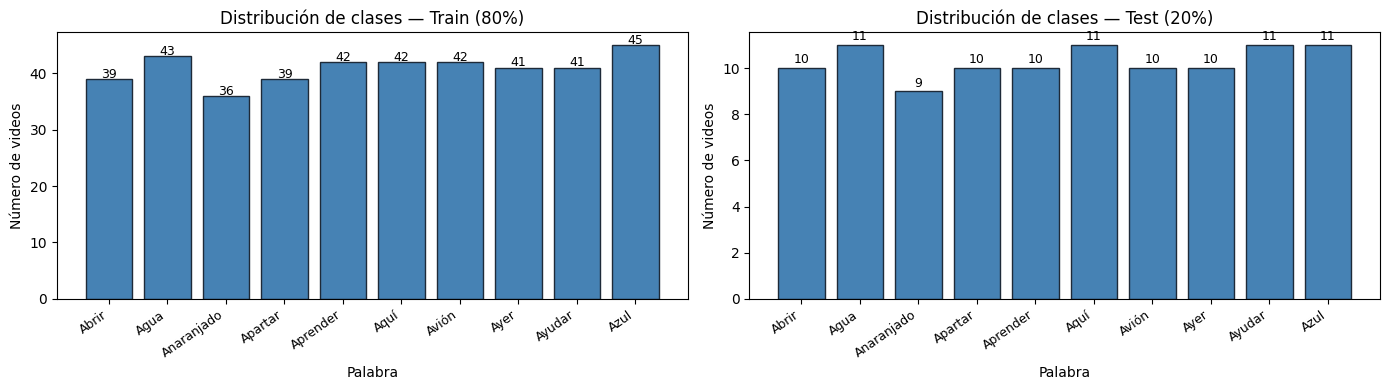

In [5]:
# ============================================================
# VISUALIZAR DISTRIBUCIÓN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title in zip(axes, [df_train, df_test], ["Train (80%)", "Test (20%)"]):
    counts = df["label"].value_counts().reindex(WORDS, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="#1e2a38")
    ax.set_title(f"Distribución de clases — {title}", fontsize=12)
    ax.set_xlabel("Palabra")
    ax.set_ylabel("Número de videos")
    ax.set_xticklabels(counts.index, rotation=35, ha='right', fontsize=9)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.2, str(v),
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## PASO 4. MediaPipe Holistic — extracción de landmarks

A diferencia de las señas de letras (que usaban solo `mp.solutions.hands`),
aquí usamos **`mp.solutions.holistic`** que devuelve en un solo paso:
-  Mano izquierda: 21 landmarks × 3 coords = **63 valores**
-  Mano derecha:   21 landmarks × 3 coords = **63 valores**
-  Pose (cuerpo):  33 landmarks × 4 coords = **132 valores** (x, y, z, visibility)

**Total por cuadro: 258 valores**

In [6]:
# ============================================================
# PASO 4. CONFIGURAR MEDIAPIPE HOLISTIC
# ============================================================

mp_holistic = mp.solutions.holistic
mp_drawing  = mp.solutions.drawing_utils


def extract_holistic_from_frame(results):
    """
    Extrae un vector de 258 valores de un resultado de MediaPipe Holistic.

    Orden:
      [0:63]   → mano izquierda  (21 lm × x,y,z)
      [63:126] → mano derecha    (21 lm × x,y,z)
      [126:258]→ pose            (33 lm × x,y,z,visibility)
    """
    vector = []

    # Mano izquierda
    if results.left_hand_landmarks:
        for lm in results.left_hand_landmarks.landmark:
            vector.extend([lm.x, lm.y, lm.z])
    else:
        vector.extend([0.0] * 63)  # sin detección → ceros

    # Mano derecha
    if results.right_hand_landmarks:
        for lm in results.right_hand_landmarks.landmark:
            vector.extend([lm.x, lm.y, lm.z])
    else:
        vector.extend([0.0] * 63)

    # Pose (cuerpo)
    if results.pose_landmarks:
        for lm in results.pose_landmarks.landmark:
            vector.extend([lm.x, lm.y, lm.z, lm.visibility])
    else:
        vector.extend([0.0] * 132)

    return vector  # 258 valores


def extract_landmarks_from_video(video_path, max_frames=MAX_FRAMES):
    """
    Lee un video y extrae landmarks Holistic frame a frame.

    Retorna:
      sequence       : np.array de shape (max_frames, 258)
      hand_det_rate  : fracción de frames con al menos una mano detectada
    """
    cap = cv2.VideoCapture(video_path)
    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()

    total = len(all_frames)
    if total == 0:
        return None, 0.0

    # Muestreo uniforme a max_frames cuadros
    if total <= max_frames:
        selected = all_frames
    else:
        indices  = np.linspace(0, total - 1, max_frames, dtype=int)
        selected = [all_frames[i] for i in indices]

    sequence     = []
    hands_frames = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        min_detection_confidence=0.4,
        min_tracking_confidence=0.4
    ) as holistic:
        for frame in selected:
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)
            vec     = extract_holistic_from_frame(results)
            sequence.append(vec)

            if results.left_hand_landmarks or results.right_hand_landmarks:
                hands_frames += 1

    # Pad con ceros si el video tenía menos de max_frames
    while len(sequence) < max_frames:
        sequence.append([0.0] * N_FEATURES_PER_FRAME)

    hand_det_rate = hands_frames / max(len(selected), 1)
    return np.array(sequence), hand_det_rate  # (max_frames, 258)


print(f"Holistic configurado")
print(f"   Features por frame : {N_FEATURES_PER_FRAME}")
print(f"   Shape por video    : ({MAX_FRAMES}, {N_FEATURES_PER_FRAME})")

Holistic configurado
   Features por frame : 258
   Shape por video    : (60, 258)


---
## PASO 5. Ingeniería de características temporales

Igual que en el notebook de letras: 6 estadísticas × 258 features/frame = **1,548 features por video**.

In [7]:
# ============================================================
# PASO 5. INGENIERÍA DE CARACTERÍSTICAS TEMPORALES
# ============================================================

def sequence_to_features(sequence):
    """
    Convierte una secuencia (max_frames, 258) en un vector 1D.

    Estadísticas calculadas (eje temporal):
      mean, std, min, max  →  4 × 258 = 1,032
      vel_mean, vel_std    →  2 × 258 = 516
    Total: 1,548 features
    """
    seq = np.array(sequence)   # (T, 258)

    # Estadísticas de posición
    mean_pos = seq.mean(axis=0)
    std_pos  = seq.std(axis=0)
    min_pos  = seq.min(axis=0)
    max_pos  = seq.max(axis=0)

    # Velocidad: diferencias frame-a-frame
    diff     = np.diff(seq, axis=0)  # (T-1, 258)
    mean_vel = diff.mean(axis=0)
    std_vel  = diff.std(axis=0)

    return np.concatenate([mean_pos, std_pos, min_pos, max_pos, mean_vel, std_vel])


FEATURE_DIM = 6 * N_FEATURES_PER_FRAME
print(f"Feature dimension: {FEATURE_DIM} por video")

Feature dimension: 1548 por video


---
## PASO 6. Procesar todos los videos (train y test)

In [8]:
# ============================================================
# PASO 6. FUNCIÓN DE PROCESAMIENTO DE SPLIT
# ============================================================

def process_split(df, split_name="split"):
    X_list = []
    y_list = []
    skipped = []
    det_rates = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Procesando {split_name}"):
        sequence, det_rate = extract_landmarks_from_video(row["path"])

        if sequence is None:
            skipped.append(row["path"])
            continue

        det_rates.append(det_rate)
        features = sequence_to_features(sequence)
        X_list.append(features)
        y_list.append(row["label"])

    X = np.array(X_list)
    y = np.array(y_list)

    print(f"\n{split_name}: {len(X)} procesados, {len(skipped)} omitidos")
    if det_rates:
        print(f"  Tasa de detección de manos: {np.mean(det_rates):.2%} (promedio)")
    return X, y

In [9]:
#   Este paso tarda varios minutos (procesa ~400 videos con Holistic).
# Guarda los arrays en disco para no reprocesar.

CACHE_DIR = "./cache_iteso"
os.makedirs(CACHE_DIR, exist_ok=True)

cache_train_X = os.path.join(CACHE_DIR, "X_train.npy")
cache_train_y = os.path.join(CACHE_DIR, "y_train.npy")
cache_test_X  = os.path.join(CACHE_DIR, "X_test.npy")
cache_test_y  = os.path.join(CACHE_DIR, "y_test.npy")

if all(os.path.exists(p) for p in [cache_train_X, cache_train_y, cache_test_X, cache_test_y]):
    print("Cargando features desde cache...")
    X_train = np.load(cache_train_X, allow_pickle=True)
    y_train = np.load(cache_train_y, allow_pickle=True)
    X_test  = np.load(cache_test_X,  allow_pickle=True)
    y_test  = np.load(cache_test_y,  allow_pickle=True)
    print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
    print(f"  X_test : {X_test.shape}   y_test : {y_test.shape}")
else:
    print("Procesando videos (primera vez, puede tardar 10-20 min)...")
    X_train, y_train = process_split(df_train, "TRAIN")
    X_test,  y_test  = process_split(df_test,  "TEST")

    np.save(cache_train_X, X_train)
    np.save(cache_train_y, y_train)
    np.save(cache_test_X,  X_test)
    np.save(cache_test_y,  y_test)
    print("Features guardadas en cache")

print(f"\nX_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

Procesando videos (primera vez, puede tardar 10-20 min)...


Procesando TRAIN: 100%|██████████| 410/410 [16:27<00:00,  2.41s/it]



TRAIN: 410 procesados, 0 omitidos
  Tasa de detección de manos: 85.94% (promedio)


Procesando TEST: 100%|██████████| 103/103 [04:19<00:00,  2.52s/it]


TEST: 103 procesados, 0 omitidos
  Tasa de detección de manos: 85.83% (promedio)
Features guardadas en cache

X_train: (410, 1548)
X_test : (103, 1548)


---
## PASO 7. Normalización

In [10]:
# ============================================================
# PASO 7. STANDARD SCALER
# ============================================================

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Normalizacion completada")
print(f"   X_train_sc : {X_train_sc.shape}")
print(f"   X_test_sc  : {X_test_sc.shape}")

Normalizacion completada
   X_train_sc : (410, 1548)
   X_test_sc  : (103, 1548)


---
## ═══════════════════════════════════════
## FASE 1 — Clasificadores clásicos (mismo enfoque que letras)
## ═══════════════════════════════════════

In [12]:
# ============================================================
# FASE 1 — ENTRENAR MODELOS CLÁSICOS
# ============================================================

models_phase1 = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=10.0,
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=RANDOM_STATE
    )
}

results_p1 = {}

for name, clf in models_phase1.items():
    print(f"\nEntrenando {name}...")
    clf.fit(X_train_sc, y_train)

    y_pred_train = clf.predict(X_train_sc)
    y_pred_test  = clf.predict(X_test_sc)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test  = accuracy_score(y_test,  y_pred_test)
    f1_test   = f1_score(y_test, y_pred_test, average="macro", zero_division=0)

    results_p1[name] = {
        "model":     clf,
        "y_pred":    y_pred_test,
        "acc_train": acc_train,
        "acc_test":  acc_test,
        "f1_macro":  f1_test
    }

    print(f"  Acc train : {acc_train:.4f}")
    print(f"  Acc test  : {acc_test:.4f}")
    print(f"  F1-macro  : {f1_test:.4f}")

print("\n Fase 1 completa")


Entrenando Random Forest...
  Acc train : 1.0000
  Acc test  : 1.0000
  F1-macro  : 1.0000

Entrenando SVM (RBF)...
  Acc train : 1.0000
  Acc test  : 1.0000
  F1-macro  : 1.0000

Entrenando Gradient Boosting...
  Acc train : 1.0000
  Acc test  : 0.9806
  F1-macro  : 0.9817

 Fase 1 completa


In [13]:
# ── Tabla de comparación Fase 1 ─────────────────────────────

df_p1 = pd.DataFrame([
    {"Modelo": n,
     "Acc Train": f"{r['acc_train']:.4f}",
     "Acc Test":  f"{r['acc_test']:.4f}",
     "F1-macro":  f"{r['f1_macro']:.4f}"}
    for n, r in results_p1.items()
])

print("=== FASE 1 — RESULTADOS ===")
print(df_p1.to_string(index=False))

best_p1 = max(results_p1, key=lambda k: results_p1[k]["f1_macro"])
print(f"\n Mejor Fase 1: {best_p1} (F1-macro = {results_p1[best_p1]['f1_macro']:.4f})")

=== FASE 1 — RESULTADOS ===
           Modelo Acc Train Acc Test F1-macro
    Random Forest    1.0000   1.0000   1.0000
        SVM (RBF)    1.0000   1.0000   1.0000
Gradient Boosting    1.0000   0.9806   0.9817

 Mejor Fase 1: Random Forest (F1-macro = 1.0000)


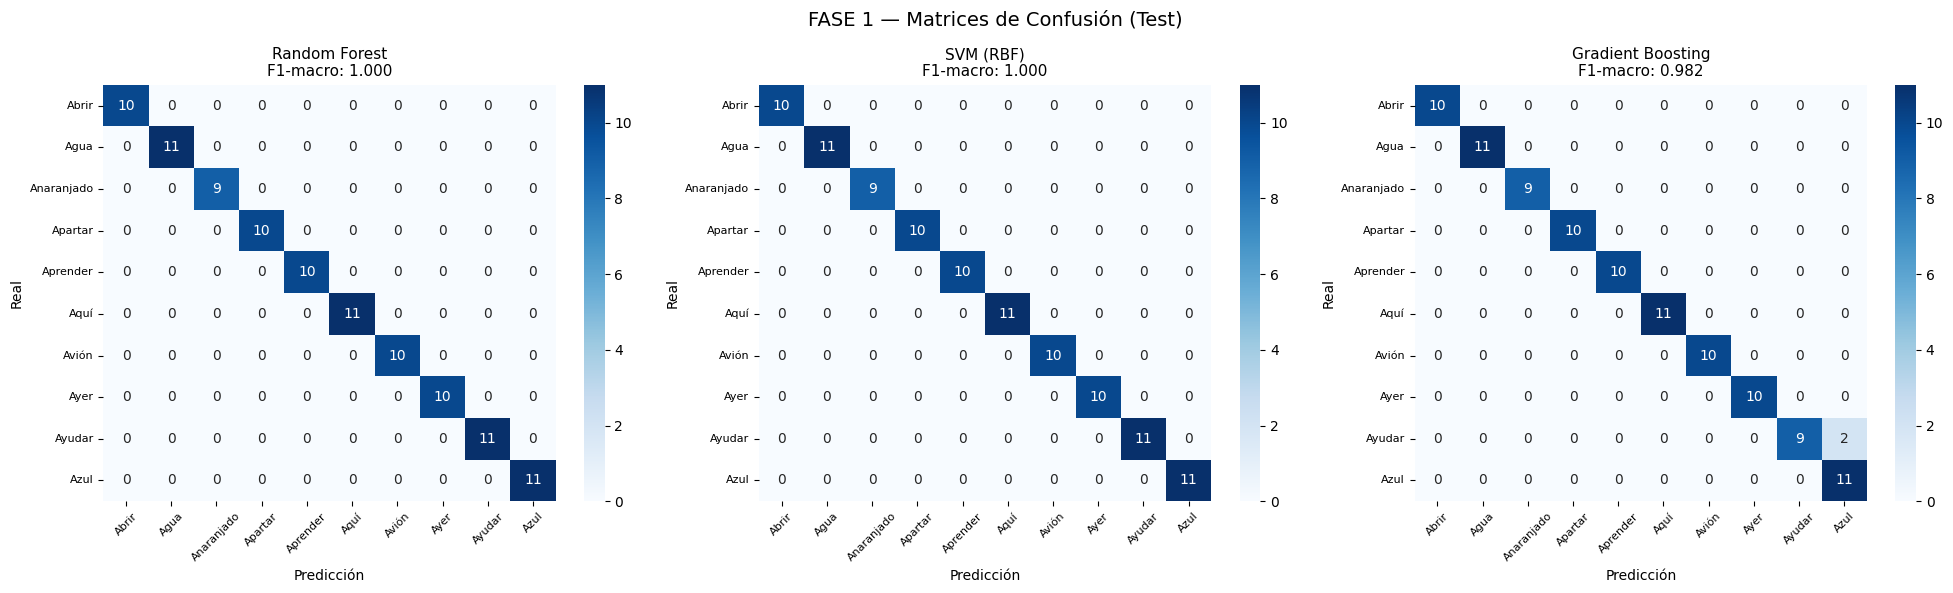

In [14]:
# ── Matrices de confusión Fase 1 ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_labels = sorted(WORDS)

for ax, (name, result) in zip(axes, results_p1.items()):
    cm = confusion_matrix(y_test, result["y_pred"], labels=class_labels)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_labels, yticklabels=class_labels, ax=ax
    )
    ax.set_title(f"{name}\nF1-macro: {result['f1_macro']:.3f}", fontsize=11)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle("FASE 1 — Matrices de Confusión (Test)", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# ── Reporte detallado del mejor modelo Fase 1 ───────────────

print(f"=== Reporte detallado: {best_p1} ===")
print(classification_report(
    y_test, results_p1[best_p1]["y_pred"],
    target_names=sorted(WORDS), zero_division=0
))

=== Reporte detallado: Random Forest ===
              precision    recall  f1-score   support

       Abrir       1.00      1.00      1.00        10
        Agua       1.00      1.00      1.00        11
  Anaranjado       1.00      1.00      1.00         9
     Apartar       1.00      1.00      1.00        10
    Aprender       1.00      1.00      1.00        10
        Aquí       1.00      1.00      1.00        11
       Avión       1.00      1.00      1.00        10
        Ayer       1.00      1.00      1.00        10
      Ayudar       1.00      1.00      1.00        11
        Azul       1.00      1.00      1.00        11

    accuracy                           1.00       103
   macro avg       1.00      1.00      1.00       103
weighted avg       1.00      1.00      1.00       103



---
## ═══════════════════════════════════════
## FASE 2 — MLP sobre secuencia aplanada
## ═══════════════════════════════════════

En lugar de resumir la secuencia con estadísticas, aplanamos directamente el array
`(60 frames × 258 features) = 15,480 valores` y los pasamos a una red neuronal
multicapa (**MLP**). Esto preserva más información temporal que la agregación.

> **¿Por qué MLP y no LSTM?** El MLP es el siguiente paso natural antes de
> añadir complejidad recurrente. Si los resultados mejoran respecto a Fase 1,
> tenemos evidencia de que la información temporal extra ayuda y vale la pena
> explorar LSTM después.

In [16]:
# ============================================================
# FASE 2 — PREPARAR DATOS: APLANAR SECUENCIA COMPLETA
# ============================================================

# Re-extraer la secuencia raw (sin agregación estadística)
# Usamos los archivos .npy del cache para no volver a llamar a Holistic.
# Nota: el cache guardó los features ya agregados (1,548 dim).
# Para Fase 2 necesitamos las secuencias raw (60, 258).
# Las regeneramos aquí solo si no existe un cache de secuencias.

CACHE_SEQ_TRAIN = os.path.join(CACHE_DIR, "seq_train.npy")
CACHE_SEQ_TEST  = os.path.join(CACHE_DIR, "seq_test.npy")


def process_split_raw(df, split_name="split"):
    """Igual que process_split pero devuelve la secuencia sin agregar."""
    X_list = []
    y_list = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Seq raw {split_name}"):
        sequence, _ = extract_landmarks_from_video(row["path"])
        if sequence is None:
            continue
        X_list.append(sequence.flatten())  # (60*258,) = (15480,)
        y_list.append(row["label"])
    return np.array(X_list), np.array(y_list)


if os.path.exists(CACHE_SEQ_TRAIN) and os.path.exists(CACHE_SEQ_TEST):
    print("Cargando secuencias raw desde cache...")
    X_train_seq = np.load(CACHE_SEQ_TRAIN, allow_pickle=True)
    X_test_seq  = np.load(CACHE_SEQ_TEST,  allow_pickle=True)
else:
    print("Extrayendo secuencias raw (puede tardar)...")
    X_train_seq, _ = process_split_raw(df_train, "TRAIN")
    X_test_seq,  _ = process_split_raw(df_test,  "TEST")
    np.save(CACHE_SEQ_TRAIN, X_train_seq)
    np.save(CACHE_SEQ_TEST,  X_test_seq)
    print("Secuencias raw guardadas en cache")

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq  shape: {X_test_seq.shape}")

Extrayendo secuencias raw (puede tardar)...


Seq raw TEST: 100%|██████████| 103/103 [03:51<00:00,  2.25s/it]

Secuencias raw guardadas en cache
X_train_seq shape: (410, 15480)
X_test_seq  shape: (103, 15480)


In [17]:
# ── Normalizar secuencias raw ────────────────────────────────

scaler_seq = StandardScaler()
X_train_seq_sc = scaler_seq.fit_transform(X_train_seq)
X_test_seq_sc  = scaler_seq.transform(X_test_seq)

print(f"Normalizacion Fase 2")
print(f"   X_train_seq_sc : {X_train_seq_sc.shape}")
print(f"   X_test_seq_sc  : {X_test_seq_sc.shape}")

Normalizacion Fase 2
   X_train_seq_sc : (410, 15480)
   X_test_seq_sc  : (103, 15480)


In [19]:
# ============================================================
# FASE 2 — ENTRENAR MLP
# ============================================================
# NOTA: MLPClassifier con early_stopping=True llama internamente a
# np.isnan() sobre las predicciones del set de validacion. Esto falla
# cuando las etiquetas son strings. Solucion: codificar y_train/y_test
# como enteros con LabelEncoder y decodificar despues de predecir.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # strings -> 0..9
y_test_enc  = le.transform(y_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),  # 3 capas ocultas
    activation="relu",
    solver="adam",
    alpha=1e-3,           # regularizacion L2
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,  # detener si val_loss no mejora
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=False
)

print("Entrenando MLP (512 -> 256 -> 128 -> 10 clases)...")
mlp.fit(X_train_seq_sc, y_train_enc)

# Decodificar predicciones de vuelta a strings
y_pred_mlp_train = le.inverse_transform(mlp.predict(X_train_seq_sc))
y_pred_mlp_test  = le.inverse_transform(mlp.predict(X_test_seq_sc))

acc_mlp_train = accuracy_score(y_train, y_pred_mlp_train)
acc_mlp_test  = accuracy_score(y_test,  y_pred_mlp_test)
f1_mlp        = f1_score(y_test, y_pred_mlp_test, average="macro", zero_division=0)

print(f"  Iteraciones realizadas : {mlp.n_iter_}")
print(f"  Acc train              : {acc_mlp_train:.4f}")
print(f"  Acc test               : {acc_mlp_test:.4f}")
print(f"  F1-macro               : {f1_mlp:.4f}")

Entrenando MLP (512 -> 256 -> 128 -> 10 clases)...
  Iteraciones realizadas : 22
  Acc train              : 0.9854
  Acc test               : 0.9903
  F1-macro               : 0.9905


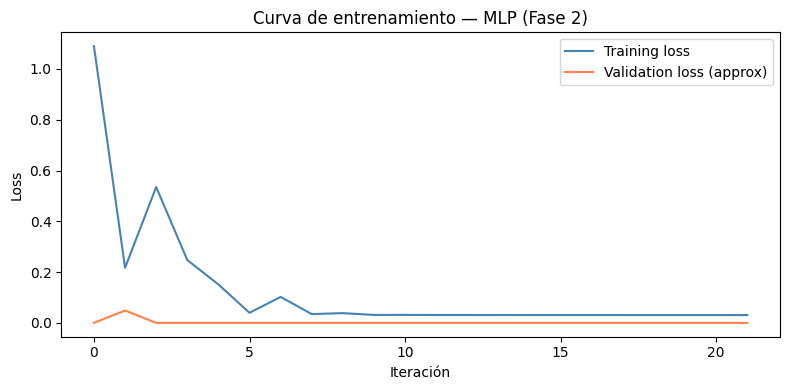

In [20]:
# ── Curva de pérdida del MLP ─────────────────────────────────

plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training loss", color="steelblue")
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    plt.plot(
        [1 - s for s in mlp.validation_scores_],
        label="Validation loss (approx)", color="coral"
    )
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento — MLP (Fase 2)")
plt.legend()
plt.tight_layout()
plt.show()

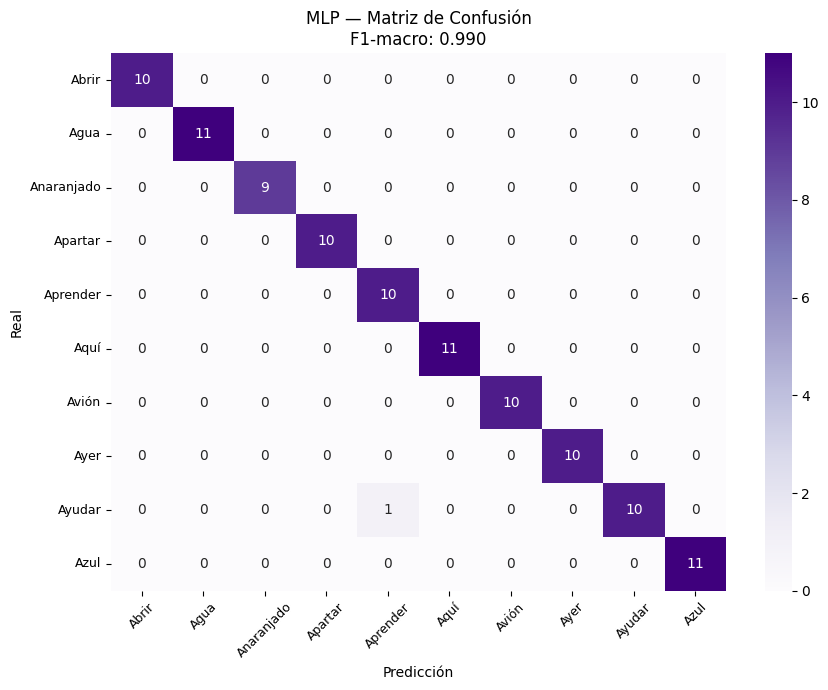

              precision    recall  f1-score   support

       Abrir       1.00      1.00      1.00        10
        Agua       1.00      1.00      1.00        11
  Anaranjado       1.00      1.00      1.00         9
     Apartar       1.00      1.00      1.00        10
    Aprender       0.91      1.00      0.95        10
        Aquí       1.00      1.00      1.00        11
       Avión       1.00      1.00      1.00        10
        Ayer       1.00      1.00      1.00        10
      Ayudar       1.00      0.91      0.95        11
        Azul       1.00      1.00      1.00        11

    accuracy                           0.99       103
   macro avg       0.99      0.99      0.99       103
weighted avg       0.99      0.99      0.99       103



In [21]:
# ── Matriz de confusión MLP ──────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 7))
cm_mlp = confusion_matrix(y_test, y_pred_mlp_test, labels=sorted(WORDS))
sns.heatmap(
    cm_mlp, annot=True, fmt="d", cmap="Purples",
    xticklabels=sorted(WORDS), yticklabels=sorted(WORDS), ax=ax
)
ax.set_title(f"MLP — Matriz de Confusión\nF1-macro: {f1_mlp:.3f}")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_mlp_test,
                             target_names=sorted(WORDS), zero_division=0))

---
## PASO 8. Comparación final Fase 1 vs Fase 2

In [22]:
# ============================================================
# COMPARACIÓN GLOBAL
# ============================================================

rows = []
for name, r in results_p1.items():
    rows.append({
        "Fase": "1 — Estadísticas",
        "Modelo": name,
        "Features": f"{FEATURE_DIM:,}",
        "Acc Train": f"{r['acc_train']:.4f}",
        "Acc Test":  f"{r['acc_test']:.4f}",
        "F1-macro":  f"{r['f1_macro']:.4f}"
    })

rows.append({
    "Fase": "2 — MLP Secuencia",
    "Modelo": "MLP (512→256→128)",
    "Features": f"{X_train_seq.shape[1]:,}",
    "Acc Train": f"{acc_mlp_train:.4f}",
    "Acc Test":  f"{acc_mlp_test:.4f}",
    "F1-macro":  f"{f1_mlp:.4f}"
})

df_final = pd.DataFrame(rows)
print("=" * 80)
print("COMPARACIÓN FINAL — FASE 1 vs FASE 2")
print("=" * 80)
print(df_final.to_string(index=False))

best_row = df_final.loc[df_final["F1-macro"].astype(float).idxmax()]
print(f"\nMejor modelo global: {best_row['Modelo']} ({best_row['Fase']})")
print(f"   F1-macro: {best_row['F1-macro']}")

COMPARACIÓN FINAL — FASE 1 vs FASE 2
             Fase            Modelo Features Acc Train Acc Test F1-macro
 1 — Estadísticas     Random Forest    1,548    1.0000   1.0000   1.0000
 1 — Estadísticas         SVM (RBF)    1,548    1.0000   1.0000   1.0000
 1 — Estadísticas Gradient Boosting    1,548    1.0000   0.9806   0.9817
2 — MLP Secuencia MLP (512→256→128)   15,480    0.9854   0.9903   0.9905

Mejor modelo global: Random Forest (1 — Estadísticas)
   F1-macro: 1.0000


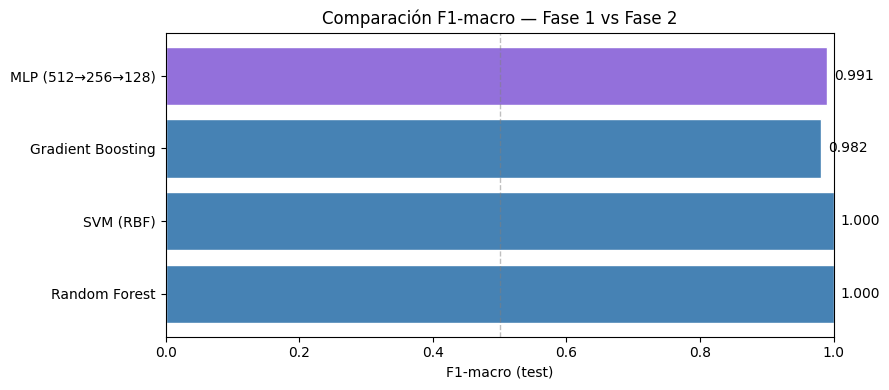

In [23]:
# ── Gráfico comparativo de F1-macro ─────────────────────────

nombres = [r["Modelo"] for r in rows]
f1s     = [float(r["F1-macro"]) for r in rows]
colores = ["steelblue"] * 3 + ["mediumpurple"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(nombres, f1s, color=colores, edgecolor="white")
ax.set_xlim(0, 1.0)
ax.set_xlabel("F1-macro (test)")
ax.set_title("Comparación F1-macro — Fase 1 vs Fase 2")
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=.5, label="Baseline 0.5")
for bar, val in zip(bars, f1s):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## PASO 9. Predicción sobre un video a elegir

In [32]:
# ============================================================
# PASO 9. FUNCION DE PREDICCION INDIVIDUAL (con preview de frames)
# ============================================================

def extract_sample_frames_with_landmarks(video_path, n_sample=6):
    """
    Extrae n_sample cuadros distribuidos uniformemente del video
    y dibuja los landmarks de Holistic sobre cada uno.
    Devuelve una lista de imagenes BGR con los landmarks.
    """
    cap = cv2.VideoCapture(video_path)
    raw_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        raw_frames.append(frame)
    cap.release()

    if not raw_frames:
        return []

    idxs = np.linspace(0, len(raw_frames) - 1, n_sample, dtype=int)
    sample = [raw_frames[i] for i in idxs]

    annotated = []
    with mp.solutions.holistic.Holistic(
        static_image_mode=True,
        min_detection_confidence=0.3
    ) as holistic_draw:
        for frame in sample:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic_draw.process(rgb)
            annotated_frame = frame.copy()

            # Dibujar mano izquierda
            if results.left_hand_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(
                    annotated_frame,
                    results.left_hand_landmarks,
                    mp.solutions.holistic.HAND_CONNECTIONS
                )
            # Dibujar mano derecha
            if results.right_hand_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(
                    annotated_frame,
                    results.right_hand_landmarks,
                    mp.solutions.holistic.HAND_CONNECTIONS
                )
            # Dibujar pose (esqueleto)
            if results.pose_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(
                    annotated_frame,
                    results.pose_landmarks,
                    mp.solutions.holistic.POSE_CONNECTIONS,
                    mp.solutions.drawing_utils.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=2),
                    mp.solutions.drawing_utils.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                )
            annotated.append(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))

    return annotated


def predict_word_video(video_path, model, scaler_obj, use_raw_seq=False):
    """
    Predice la palabra de un video MP4 usando el modelo dado.

    Parametros:
      use_raw_seq : True  -> usa la secuencia aplanada (Fase 2 / MLP)
                    False -> usa features estadisticas (Fase 1)
    """
    sequence, det_rate = extract_landmarks_from_video(video_path)
    if sequence is None:
        raise ValueError(f"No se pudo leer el video: {video_path}")

    if use_raw_seq:
        feat = sequence.flatten().reshape(1, -1)
    else:
        feat = sequence_to_features(sequence).reshape(1, -1)

    feat_sc = scaler_obj.transform(feat)
    pred    = model.predict(feat_sc)[0]

    # Probabilidades
    if hasattr(model, 'predict_proba'):
        proba = dict(zip(model.classes_, model.predict_proba(feat_sc)[0]))
    elif hasattr(model, 'decision_function'):
        sc = model.decision_function(feat_sc)[0]
        exp_s = np.exp(sc - sc.max())
        proba = dict(zip(model.classes_, exp_s / exp_s.sum()))
    else:
        proba = {c: (1. if c == pred else 0.) for c in WORDS}

    # Map predictions and probabilities keys if they are integers
    classes_are_ints = False
    if len(model.classes_) > 0:
        first_cls = model.classes_[0]
        if isinstance(first_cls, (int, np.integer)):
            classes_are_ints = True

    if classes_are_ints:
        pred_label = WORDS[int(pred)]
        proba_mapped = {}
        for c, p in proba.items():
            proba_mapped[WORDS[int(c)]] = p
        proba = proba_mapped
    else:
        pred_label = pred

    return pred_label, proba, det_rate


def show_word_prediction(video_path, model, scaler_obj, use_raw_seq=False, model_name="Modelo"):
    pred, probs, det_rate = predict_word_video(video_path, model, scaler_obj, use_raw_seq)

    print(f"\n{'='*50}")
    print(f"  Archivo       : {os.path.basename(video_path)}")
    print(f"  Modelo        : {model_name}")
    print(f"  Palabra pred  : {pred}")
    print(f"  Det. manos    : {det_rate:.0%} de cuadros")
    print(f"{'='*50}")

    # Extraer frames con landmarks para el preview
    sample_frames = extract_sample_frames_with_landmarks(video_path, n_sample=6)

    labels_s = sorted(probs.keys())
    values_s = [probs[k] for k in labels_s]
    colors   = ['#2ecc71' if l == pred else '#95a5a6' for l in labels_s]

    n_frames = len(sample_frames)
    has_frames = n_frames > 0

    if has_frames:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                                 gridspec_kw={'width_ratios': [1, 2]})
    else:
        fig, axes_arr = plt.subplots(1, 1, figsize=(6, 4))
        axes = [axes_arr, None]

    # Barras de probabilidad
    axes[0].barh(labels_s, values_s, color=colors)
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel('Probabilidad / Score')
    axes[0].set_title(f'Prediccion: {pred}  |  {model_name}', fontweight='bold')
    for i, v in enumerate(values_s):
        axes[0].text(min(v + 0.01, 0.98), i, f'{v:.1%}', va='center', fontsize=9)

    # Cuadros con landmarks
    if has_frames and axes[1] is not None:
        strip = np.concatenate(
            [cv2.resize(f, (160, 120)) for f in sample_frames], axis=1
        )
        axes[1].imshow(strip)
        axes[1].axis('off')
        axes[1].set_title(f'Cuadros de muestra con landmarks ({n_frames} mostrados)')

    plt.tight_layout()
    plt.show()


print("Funcion de prediccion lista")

Funcion de prediccion lista


---
## PASO 10. Guardar y cargar modelos

`joblib` serializa todos los modelos y scalers de Fase 1 y Fase 2.

In [25]:
# ============================================================
# GUARDAR MODELOS ENTRENADOS (FASE 1 + FASE 2)
# ============================================================
import joblib, os

MODELS_DIR = "./models_word_signs"
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Fase 1: clasificadores clásicos + scaler ────────────────
for name, result in results_p1.items():
    safe_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    path = os.path.join(MODELS_DIR, f"p1_{safe_name}.joblib")
    joblib.dump(result["model"], path)
    print(f"  [guardado] {name:20s} → {path}")

joblib.dump(scaler,     os.path.join(MODELS_DIR, "scaler_p1.joblib"))
print(f"  [guardado] Scaler Fase 1      → {MODELS_DIR}/scaler_p1.joblib")

# ── Fase 2: MLP + su propio scaler ─────────────────────────
joblib.dump(mlp,        os.path.join(MODELS_DIR, "mlp_p2.joblib"))
joblib.dump(scaler_seq, os.path.join(MODELS_DIR, "scaler_p2.joblib"))
print(f"  [guardado] MLP Fase 2         → {MODELS_DIR}/mlp_p2.joblib")
print(f"  [guardado] Scaler Fase 2      → {MODELS_DIR}/scaler_p2.joblib")

print(f"\nModelos guardados en '{MODELS_DIR}/'")


  [guardado] Random Forest        → ./models_word_signs\p1_Random_Forest.joblib
  [guardado] SVM (RBF)            → ./models_word_signs\p1_SVM_RBF.joblib
  [guardado] Gradient Boosting    → ./models_word_signs\p1_Gradient_Boosting.joblib
  [guardado] Scaler Fase 1      → ./models_word_signs/scaler_p1.joblib
  [guardado] MLP Fase 2         → ./models_word_signs/mlp_p2.joblib
  [guardado] Scaler Fase 2      → ./models_word_signs/scaler_p2.joblib

Modelos guardados en './models_word_signs/'


### Cargar modelos en una sesión nueva

Ejecuta **solo** esta celda para recuperar todos los modelos sin reentrenar.

In [26]:
# ============================================================
# CARGAR MODELOS PREVIAMENTE ENTRENADOS
# ============================================================
import joblib, os

MODELS_DIR = "./models_word_signs"

# ── Fase 1 ──────────────────────────────────────────────────
MODEL_FILES_P1 = {
    "Random Forest":     "p1_Random_Forest.joblib",
    "SVM (RBF)":         "p1_SVM_RBF.joblib",
    "Gradient Boosting": "p1_Gradient_Boosting.joblib",
}

results_p1_loaded = {}
for name, fname in MODEL_FILES_P1.items():
    path = os.path.join(MODELS_DIR, fname)
    if os.path.exists(path):
        results_p1_loaded[name] = {"model": joblib.load(path)}
        print(f"  [cargado]  {name:20s} cargado")
    else:
        print(f"  [no encontrado] {name:20s} NO encontrado")

scaler_p1_loaded = None
sp1 = os.path.join(MODELS_DIR, "scaler_p1.joblib")
if os.path.exists(sp1):
    scaler_p1_loaded = joblib.load(sp1)
    print(f"  [cargado]  Scaler Fase 1      cargado")

# ── Fase 2 ──────────────────────────────────────────────────
mlp_loaded = scaler_p2_loaded = None
mp2 = os.path.join(MODELS_DIR, "mlp_p2.joblib")
sp2 = os.path.join(MODELS_DIR, "scaler_p2.joblib")

if os.path.exists(mp2):
    mlp_loaded = joblib.load(mp2)
    print(f"  [cargado]  MLP Fase 2         cargado")
if os.path.exists(sp2):
    scaler_p2_loaded = joblib.load(sp2)
    print(f"  [cargado]  Scaler Fase 2      cargado")

# Para predecir:
#   Fase 1 → results_p1_loaded["Random Forest"]["model"].predict(scaler_p1_loaded.transform(X))
#   Fase 2 → mlp_loaded.predict(scaler_p2_loaded.transform(X_seq))
print("\nListo. Usa '*_loaded' para predecir sin reentrenar.")


  [cargado]  Random Forest        cargado
  [cargado]  SVM (RBF)            cargado
  [cargado]  Gradient Boosting    cargado
  [cargado]  Scaler Fase 1      cargado
  [cargado]  MLP Fase 2         cargado
  [cargado]  Scaler Fase 2      cargado

Listo. Usa '*_loaded' para predecir sin reentrenar.



  Archivo       : 5.mp4
  Modelo        : Fase 1 — Random Forest
  Palabra pred  : Apartar
  Det. manos    : 93% de cuadros


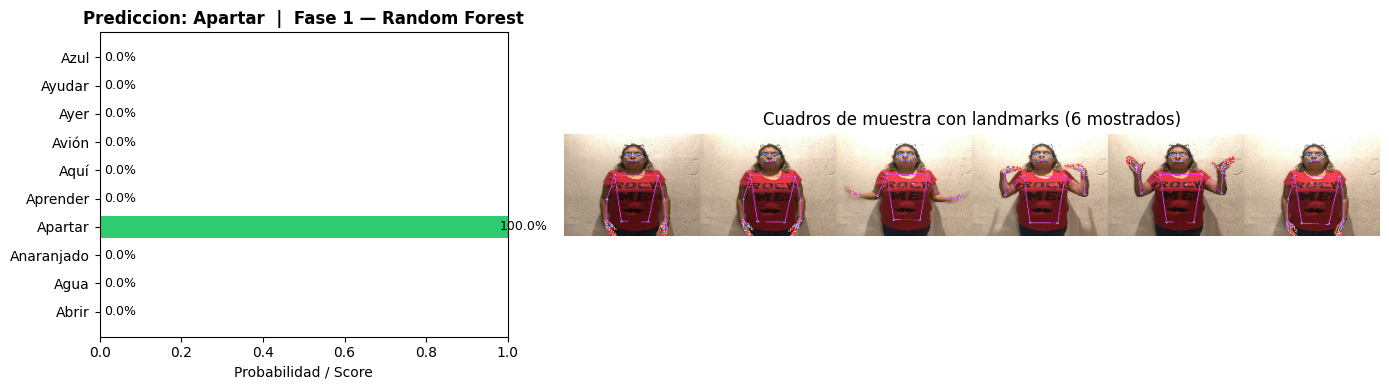


  Archivo       : 5.mp4
  Modelo        : Fase 2 — MLP
  Palabra pred  : Apartar
  Det. manos    : 93% de cuadros


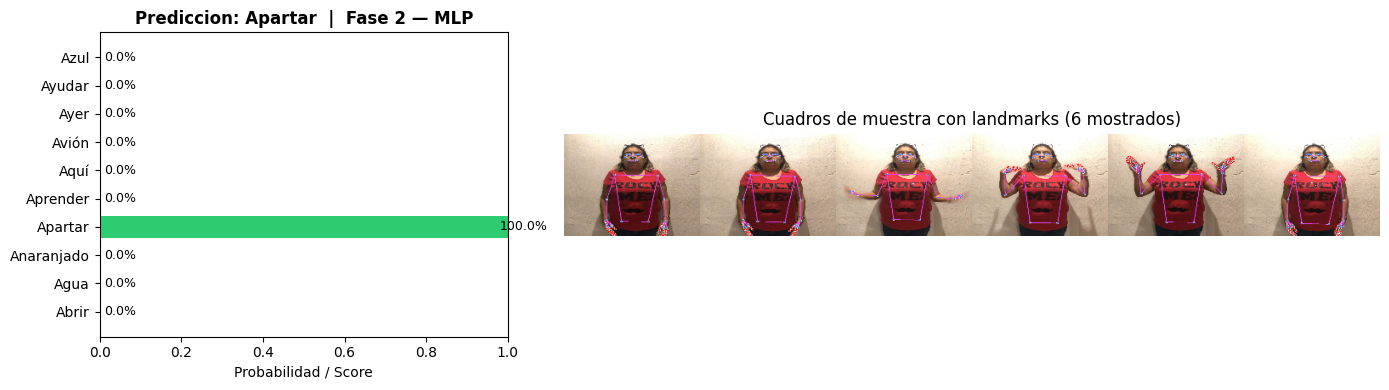

In [33]:
# ============================================================
# Diálogo de selección de archivo
# ============================================================

import tkinter as tk
from tkinter import filedialog, simpledialog

root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

video_path_dialog = filedialog.askopenfilename(
    title="Selecciona un video de seña de palabra",
    filetypes=[("Archivos de video", "*.mp4 *.avi *.mov"),
               ("Todos", "*.*")]
)
root.destroy()

if video_path_dialog:
    # Usar el mejor modelo de Fase 1
    show_word_prediction(
        video_path_dialog,
        model=results_p1[best_p1]["model"],
        scaler_obj=scaler,
        use_raw_seq=False,
        model_name=f"Fase 1 — {best_p1}"
    )
    # También predecir con MLP
    show_word_prediction(
        video_path_dialog,
        model=mlp,
        scaler_obj=scaler_seq,
        use_raw_seq=True,
        model_name="Fase 2 — MLP"
    )
else:
    print("No se selecciono ningun archivo.")